In [1]:
#EDA Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
#Preprocessing Library
from sklearn.preprocessing import StandardScaler

#Forecasting Library
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import statsmodels.api as sm
#Evaluation
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# **LOAD DATASET**

In [2]:
df = pd.read_csv("dataframe_baru.csv")
df['waktu'] = pd.to_datetime(df['waktu'])
df = df.set_index('waktu')
df = df.sort_index()

In [3]:
df_copy = df.copy()

In [4]:
df_copy['month'] = df_copy.index.month
df_copy['year'] = df_copy.index.year

df_copy['week_of_month'] = ((df_copy.index.day - 1) // 7) + 1

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 83 entries, 2024-01-07 to 2025-08-03
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   frekuensi            83 non-null     int64  
 1   total_nominal_klaim  83 non-null     float64
 2   avg_age              83 non-null     float64
 3   mean_biaya_rs        83 non-null     float64
 4   median_biaya_rs      83 non-null     float64
 5   mean_los             83 non-null     float64
 6   severitas            83 non-null     float64
 7   pct_inpatient        83 non-null     float64
 8   pct_cashless         83 non-null     float64
 9   pct_male             83 non-null     float64
 10  pct_kanker           83 non-null     float64
 11  pct_genitourinaria   83 non-null     float64
 12  pct_mata_telinga     83 non-null     float64
 13  pct_ind              83 non-null     float64
 14  pct_sg               83 non-null     float64
 15  pct_malay            8

# **Plotting**

In [6]:
def visualization(df, col):
    plt.figure(figsize=(8, 4))
    plt.plot(df.index, df[col])

    plt.title(f'{col} Over Time')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

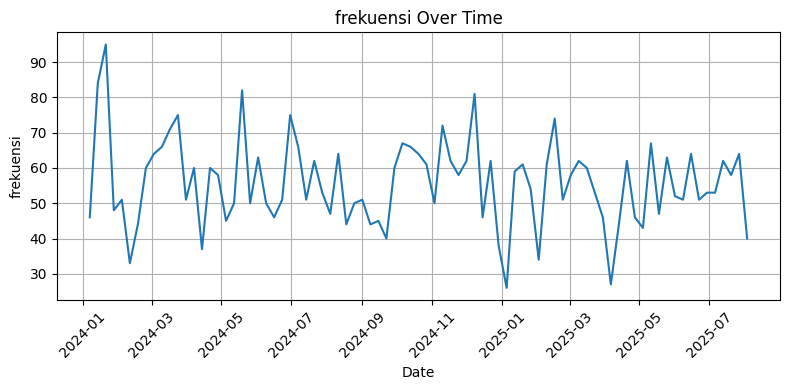

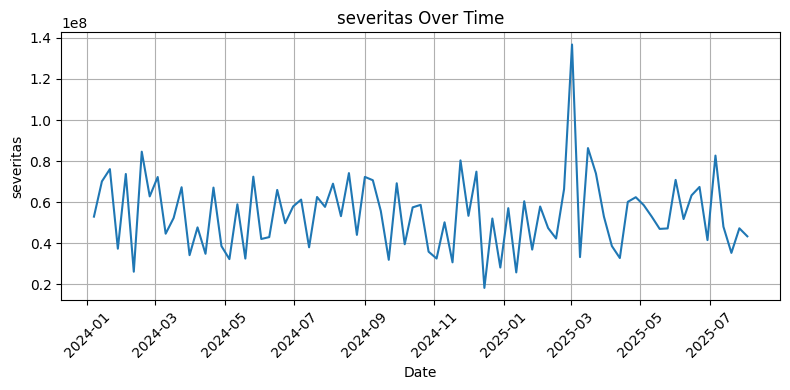

In [7]:
col = ['frekuensi', 'severitas']
for i in col:
    visualization(df, i)

Trend

In [8]:
def moving_avarage(df, col_to_use, ma_cols ,window_size=False):
  df_copy = df.copy()
  df_copy[ma_cols] = df_copy[col_to_use].rolling(window=window_size).mean()
  return df_copy

def exponential_moving_average(df, col, ema_col, span):
    df = df.copy()
    df[ema_col] = df[col].ewm(span=span, adjust=False).mean()
    return df

def plotting_ma(df, col_to_use, ma_cols):
  plt.figure(figsize=(8, 4))
  plt.plot(df.index, df[col_to_use], label=col_to_use)
  plt.plot(df.index, df[ma_cols], label=ma_cols)
  plt.title(f'{col_to_use} and {ma_cols} Over Time')
  plt.xlabel('Date')
  plt.ylabel(col_to_use)
  plt.show()

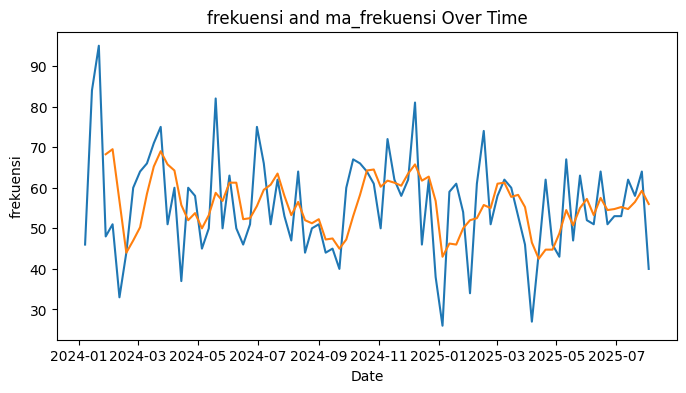

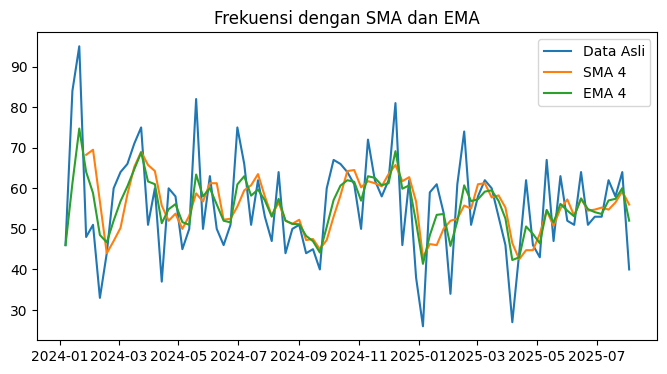

In [9]:
df_with_ma_freq = moving_avarage(df_copy, 'frekuensi', 'ma_frekuensi', 4)
df_with_ema_freq = exponential_moving_average(df_copy, 'frekuensi', 'ema_frekuensi', 4)

plotting_ma(df_with_ma_freq, 'frekuensi', 'ma_frekuensi')
plt.figure(figsize=(8,4))

plt.plot(df_copy.index, df_copy['frekuensi'], label='Data Asli')
plt.plot(df_with_ma_freq['ma_frekuensi'], label='SMA 4')
plt.plot(df_with_ema_freq['ema_frekuensi'], label='EMA 4')

plt.title('Frekuensi dengan SMA dan EMA')
plt.legend()
plt.show()

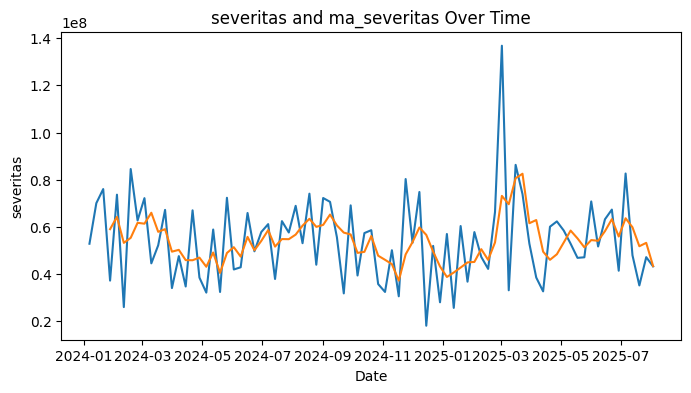

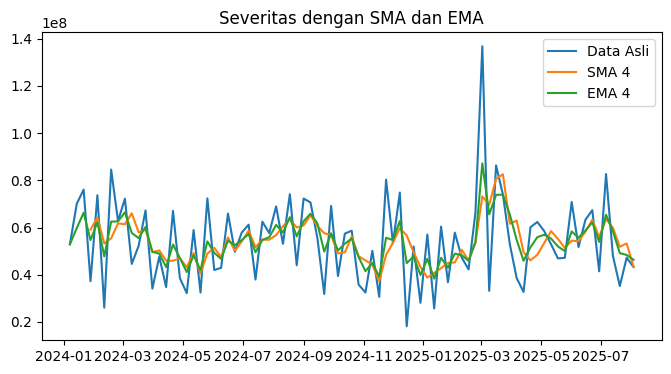

In [10]:
df_with_ma_sev = moving_avarage(df_copy, 'severitas', 'ma_severitas', 4)
df_with_ema_sev = exponential_moving_average(df_copy, 'severitas', 'ema_severitas', 4)
plotting_ma(df_with_ma_sev, 'severitas', 'ma_severitas')
plt.figure(figsize=(8,4))

plt.plot(df_copy.index, df_copy['severitas'], label='Data Asli')
plt.plot(df_with_ma_sev['ma_severitas'], label='SMA 4')
plt.plot(df_with_ema_sev['ema_severitas'], label='EMA 4')

plt.title('Severitas dengan SMA dan EMA')
plt.legend()
plt.show()

Seasonal

In [11]:
df_copy.head(10)

,frekuensi,total_nominal_klaim,avg_age,mean_biaya_rs,median_biaya_rs,mean_los,severitas,pct_inpatient,pct_cashless,pct_male,pct_kanker,pct_genitourinaria,pct_mata_telinga,pct_ind,pct_sg,pct_malay,month,year,week_of_month
waktu,,,,,,,,,,,,,,,,,,,
2024-01-07,46,2.433246e+09,61.521739,5.663807e+07,15346374.50,1.826087,5.289665e+07,0.586957,0.0,0.413043,0.217391,0.195652,0.108696,0.739130,0.195652,0.043478,1,2024,1
2024-01-14,84,5.887795e+09,62.642857,8.193885e+07,19642841.50,1.535714,7.009280e+07,0.785714,0.0,0.523810,0.214286,0.083333,0.107143,0.726190,0.190476,0.071429,1,2024,2
2024-01-21,95,7.226359e+09,62.189474,1.001810e+08,17420519.00,1.694737,7.606694e+07,0.768421,0.0,0.610526,0.126316,0.136842,0.052632,0.589474,0.210526,0.126316,1,2024,3
2024-01-28,48,1.788987e+09,60.604167,4.439584e+07,12196032.00,1.312500,3.727055e+07,0.625000,0.0,0.583333,0.229167,0.145833,0.083333,0.708333,0.208333,0.062500,1,2024,4
2024-02-04,51,3.758074e+09,58.980392,8.018652e+07,20780500.00,1.333333,7.368772e+07,0.568627,0.0,0.509804,0.294118,0.196078,0.019608,0.725490,0.235294,0.019608,2,2024,1
2024-02-11,33,8.596770e+08,62.939394,2.823468e+07,18103000.00,1.757576,2.605082e+07,0.666667,0.0,0.545455,0.151515,0.121212,0.090909,0.939394,0.030303,0.000000,2,2024,2
2024-02-18,44,3.720538e+09,60.227273,9.952557e+07,17400197.32,1.545455,8.455769e+07,0.636364,0.0,0.613636,0.204545,0.159091,0.068182,0.636364,0.363636,0.000000,2,2024,3
2024-02-25,60,3.765716e+09,59.466667,6.606182e+07,20779432.50,1.733333,6.276193e+07,0.683333,0.0,0.516667,0.200000,0.150000,0.100000,0.633333,0.266667,0.083333,2,2024,4
2024-03-03,64,4.622025e+09,59.375000,7.984073e+07,18738938.50,1.812500,7.221914e+07,0.750000,0.0,0.578125,0.171875,0.109375,0.171875,0.578125,0.203125,0.187500,3,2024,1


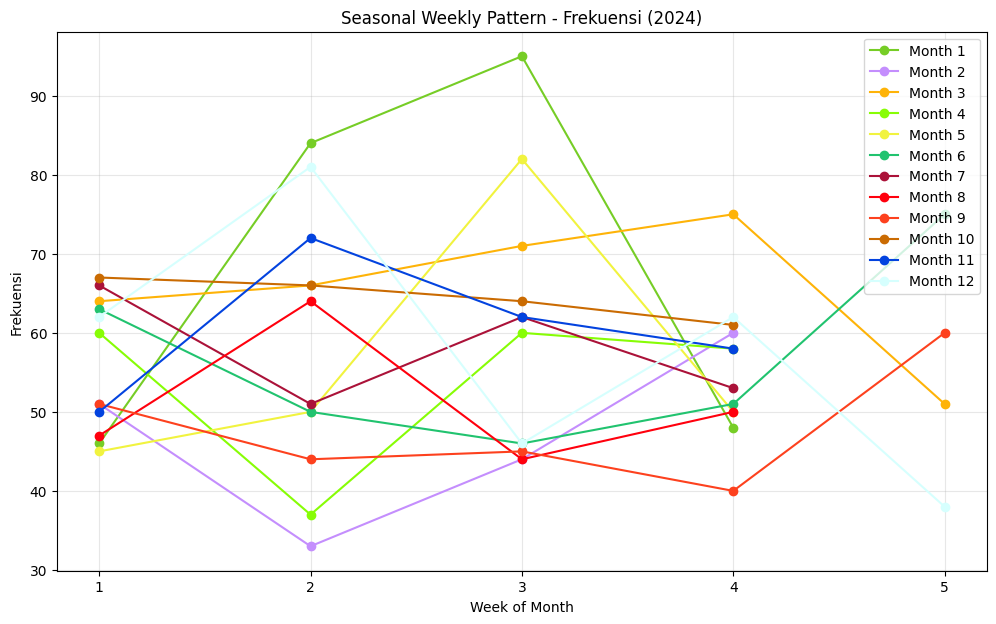

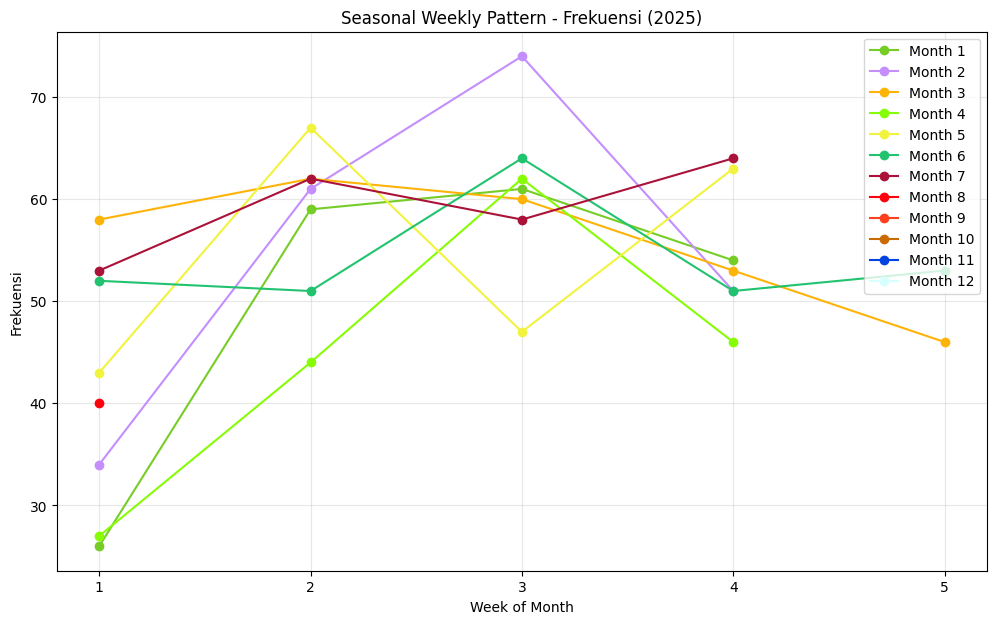

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

months = df_copy['month'].unique()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

# ===== 2024 =====
df_2024 = df_copy[df_copy['year'] == 2024]

plt.figure(figsize=(12,7))

for i, m in enumerate(months):

    data = df_2024[df_2024['month'] == m]

    plt.plot(
        data['week_of_month'],
        data['frekuensi'],
        marker='o',
        color=colors[i],
        label=f"Month {m}"
    )

plt.title("Seasonal Weekly Pattern - Frekuensi (2024)")
plt.xlabel("Week of Month")
plt.ylabel("Frekuensi")
plt.xticks([1,2,3,4,5])
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# ===== 2025 =====
df_2025 = df_copy[df_copy['year'] == 2025]

plt.figure(figsize=(12,7))

for i, m in enumerate(months):

    data = df_2025[df_2025['month'] == m]

    plt.plot(
        data['week_of_month'],
        data['frekuensi'],
        marker='o',
        color=colors[i],
        label=f"Month {m}"
    )

plt.title("Seasonal Weekly Pattern - Frekuensi (2025)")
plt.xlabel("Week of Month")
plt.ylabel("Frekuensi")
plt.xticks([1,2,3,4,5])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

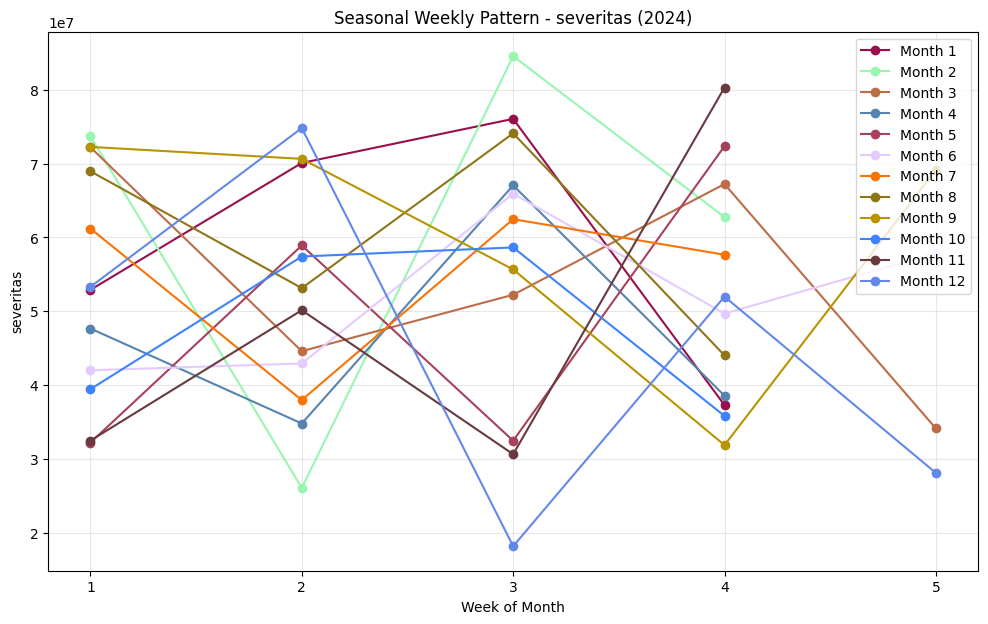

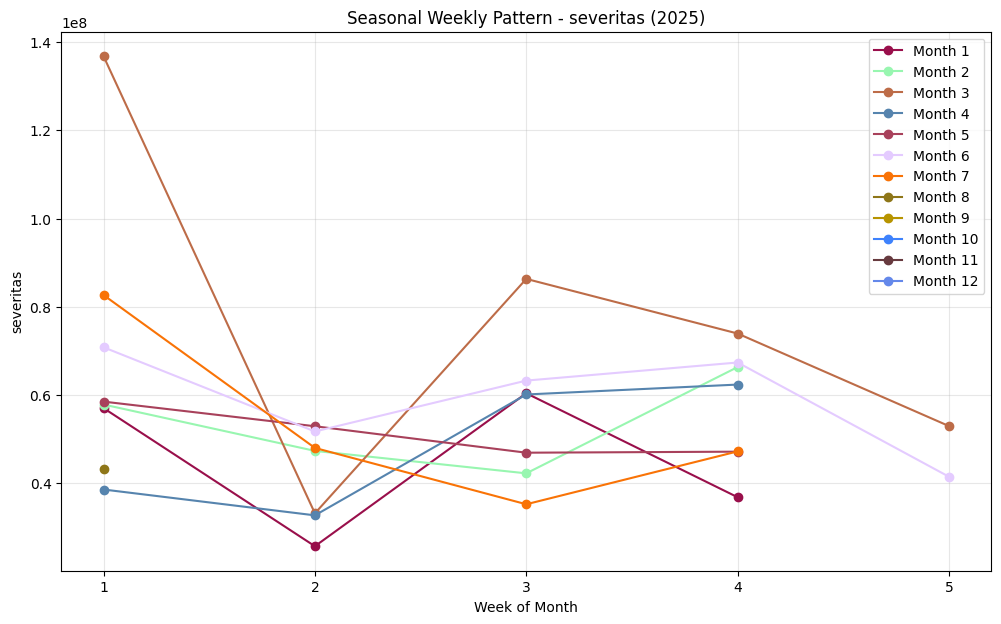

In [13]:
months = df_copy['month'].unique()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

# ===== 2024 =====
df_2024 = df_copy[df_copy['year'] == 2024]

plt.figure(figsize=(12,7))

for i, m in enumerate(months):

    data = df_2024[df_2024['month'] == m]

    plt.plot(
        data['week_of_month'],
        data['severitas'],
        marker='o',
        color=colors[i],
        label=f"Month {m}"
    )

plt.title("Seasonal Weekly Pattern - severitas (2024)")
plt.xlabel("Week of Month")
plt.ylabel("severitas")
plt.xticks([1,2,3,4,5])
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# ===== 2025 =====
df_2025 = df_copy[df_copy['year'] == 2025]

plt.figure(figsize=(12,7))

for i, m in enumerate(months):

    data = df_2025[df_2025['month'] == m]

    plt.plot(
        data['week_of_month'],
        data['severitas'],
        marker='o',
        color=colors[i],
        label=f"Month {m}"
    )

plt.title("Seasonal Weekly Pattern - severitas (2025)")
plt.xlabel("Week of Month")
plt.ylabel("severitas")
plt.xticks([1,2,3,4,5])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

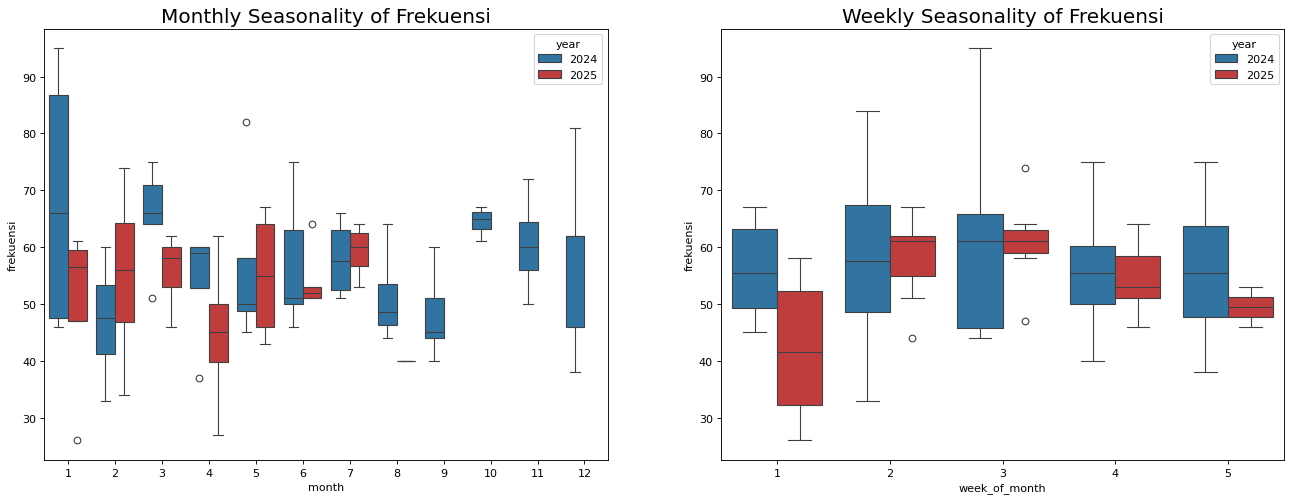

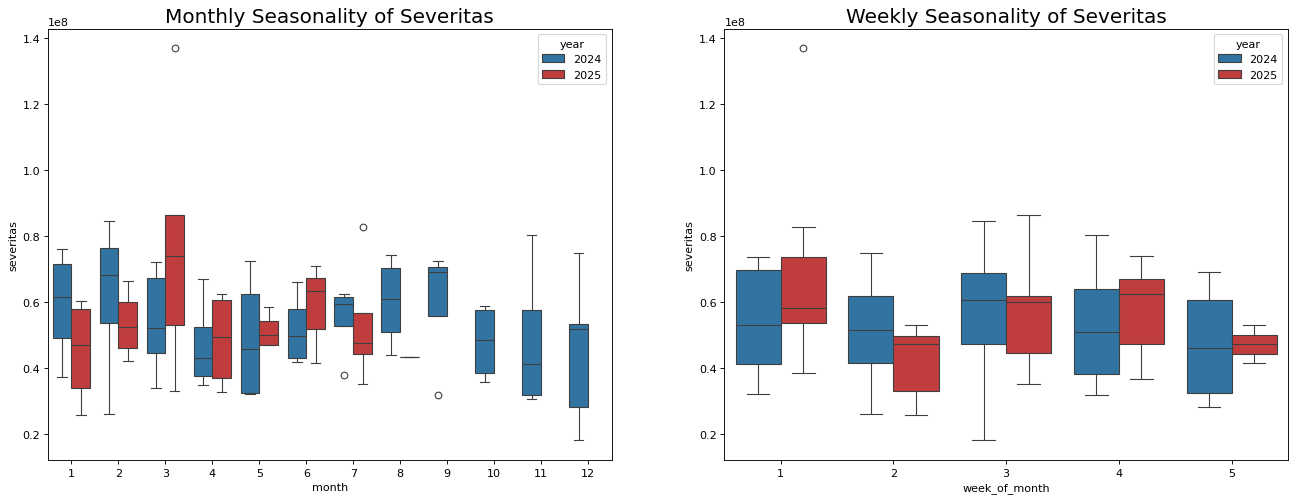

In [14]:
#Frekuensi
palette = {
    2024: "#1f77b4",
    2025: "#d62728"
}

fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi=80)

sns.boxplot(
    x='month',
    y='frekuensi',
    hue='year',
    data=df_copy,
    palette=palette,
    ax=axes[0]
)

sns.boxplot(
    x='week_of_month',
    y='frekuensi',
    hue='year',
    data=df_copy,
    palette=palette,
    ax=axes[1]
)

axes[0].set_title('Monthly Seasonality of Frekuensi', fontsize=18)
axes[1].set_title('Weekly Seasonality of Frekuensi', fontsize=18)

plt.show()

#Severitas
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi=80)

# Seasonality per month
sns.boxplot(
    x='month',
    y='severitas',
    hue='year',
    data=df_copy,
    palette=palette,
    ax=axes[0]
)

# Seasonality per week of month
sns.boxplot(
    x='week_of_month',
    y='severitas',
    hue='year',
    data=df_copy,
    palette=palette,
    ax=axes[1]
)

axes[0].set_title('Monthly Seasonality of Severitas', fontsize=18)
axes[1].set_title('Weekly Seasonality of Severitas', fontsize=18)

plt.show()

**STATIONARITY**

In [15]:
def adf_test(series):
  series = series.dropna()
  adf_test = adfuller(series)
  print("ADF Statistic: " , adf_test[0])
  print("p-value: " , adf_test[1])
  if adf_test[1] <= 0.05:
    print("Reject Null Hypothesis")
  else:
    print("Fail to Reject Null Hypothesis")

In [16]:
adf_test(df_copy['frekuensi'])
adf_test(df_copy['severitas'])

ADF Statistic:  -7.6935258902610535
p-value:  1.3987506448880093e-11
Reject Null Hypothesis
ADF Statistic:  -5.651265958122873
p-value:  9.848188580253541e-07
Reject Null Hypothesis


# **SEASONAL DECOMPOSITION**

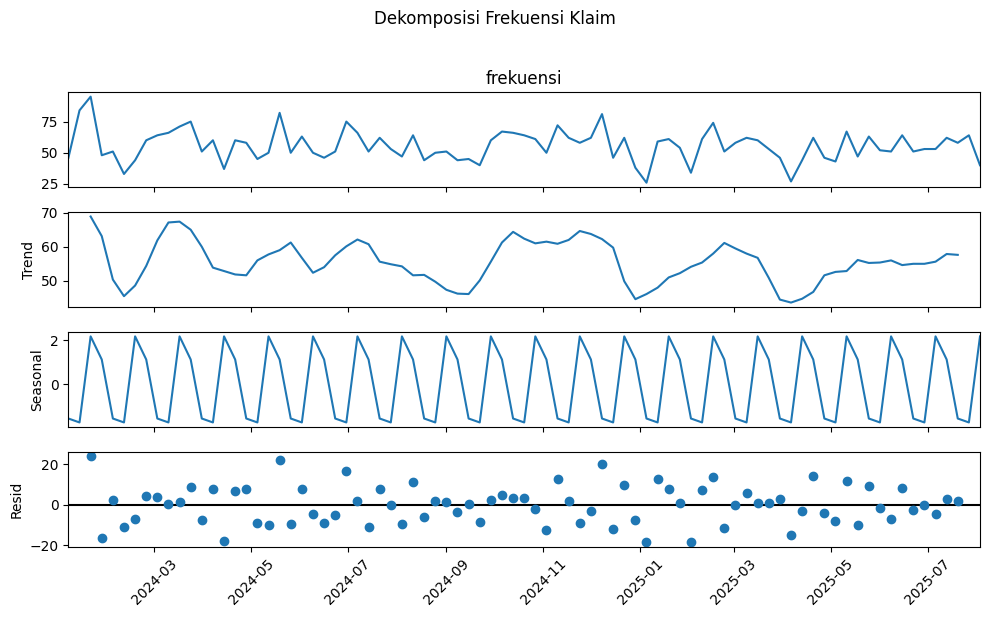

In [17]:
decom_frekuensi = seasonal_decompose(df['frekuensi'], model='additive', period=4)
decom_severitas = seasonal_decompose(df['severitas'], model='additive', period=4)

fig_frekuensi = decom_frekuensi.plot()
fig_frekuensi.set_size_inches(10,6)

plt.suptitle('Dekomposisi Frekuensi Klaim', y=1.02)

plt.xticks(rotation=45)   # supaya tanggal tidak numpuk
plt.tight_layout()

plt.show()

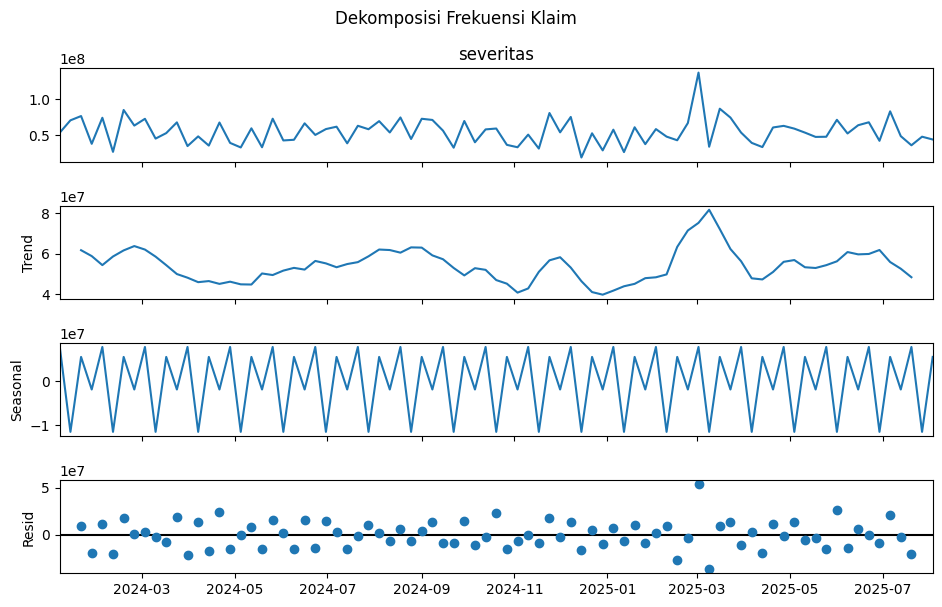

In [18]:
fig_frekuensi = decom_severitas.plot()
fig_frekuensi.set_size_inches(10, 6)
plt.suptitle('Dekomposisi Frekuensi Klaim', y=1.02)
plt.show()

# **AUTOCORRELATION**

In [19]:
from pandas.plotting import lag_plot
def acf_pacf(series,cols):
  plt.figure(figsize=(6,3))
  plot_acf(series)
  plt.title(f'Autocorrelation Function {cols}')
  plt.xlabel('Lag')
  plt.ylabel('Correlation')
  plt.show()

  plt.figure(figsize=(5,2))
  plot_pacf(series)
  plt.title(f'Partial Autocorrelation Function {cols}')
  plt.xlabel('Lag')
  plt.ylabel('Correlation')
  plt.show()

<Figure size 600x300 with 0 Axes>

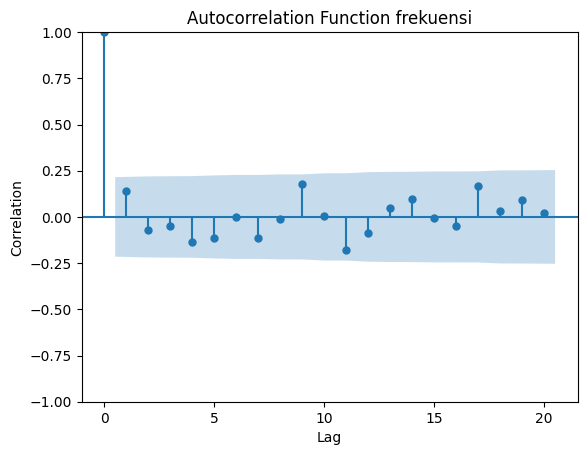

<Figure size 500x200 with 0 Axes>

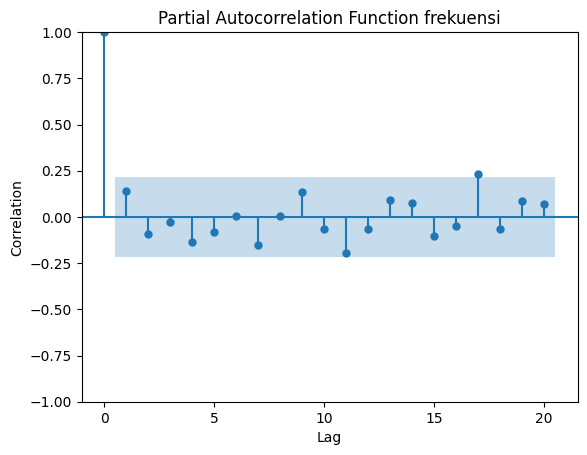

<Figure size 600x300 with 0 Axes>

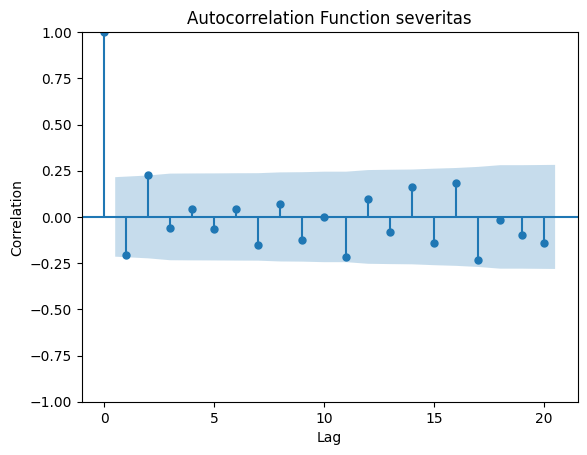

<Figure size 500x200 with 0 Axes>

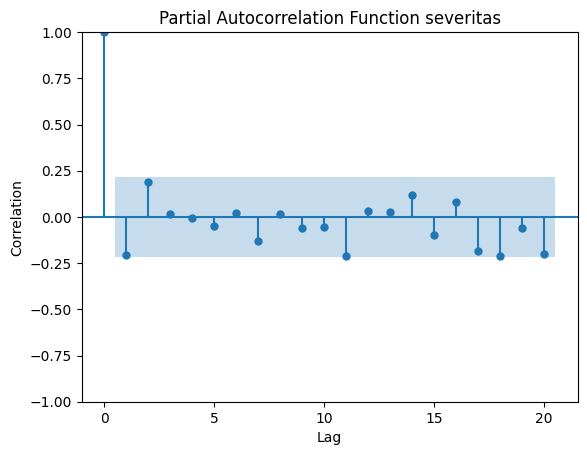

In [20]:
acf_pacf(df_copy['frekuensi'], 'frekuensi')
acf_pacf(df_copy['severitas'], 'severitas')

# **EXOGENOUS VARIABLE**

**FREQUENCY SECTION**

In [21]:
target = "frekuensi"

exog_vars = [
    "week_of_month",
    "month",
    "severitas",
    "avg_age",
    "mean_biaya_rs",
    "median_biaya_rs",
    "mean_los",
    "pct_inpatient",
    "pct_male",
    "pct_kanker",
    "pct_genitourinaria",
    "pct_mata_telinga",
    "pct_ind",
    "pct_sg",
    "pct_malay"
]

for var in exog_vars:
    print(f"\n============= {target} & {var} =============")

    data = df_copy[[target, var]].dropna()

    grangercausalitytests(data, maxlag=2)


============= frekuensi & week_of_month =============

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.1567  , p=0.0152  , df_denom=79, df_num=1
ssr based chi2 test:   chi2=6.3905  , p=0.0115  , df=1
likelihood ratio test: chi2=6.1537  , p=0.0131  , df=1
parameter F test:         F=6.1567  , p=0.0152  , df_denom=79, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.8649  , p=0.0632  , df_denom=76, df_num=2
ssr based chi2 test:   chi2=6.1067  , p=0.0472  , df=2
likelihood ratio test: chi2=5.8875  , p=0.0527  , df=2
parameter F test:         F=2.8649  , p=0.0632  , df_denom=76, df_num=2

============= frekuensi & month =============

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3415  , p=0.5606  , df_denom=79, df_num=1
ssr based chi2 test:   chi2=0.3545  , p=0.5516  , df=1
likelihood ratio test: chi2=0.3537  , p=0.5520  , df=1
parameter F test:         F=0.3415  , p=0.5606  , df_denom=79, df_num=

In [22]:
from statsmodels.tsa.stattools import grangercausalitytests

target = "severitas"

exog_vars = [
    "week_of_month",
    "month",
    "frekuensi",
    "avg_age",
    "mean_biaya_rs",
    "median_biaya_rs",
    "mean_los",
    "pct_inpatient",
    "pct_cashless",
    "pct_male",
    "pct_kanker",
    "pct_genitourinaria",
    "pct_mata_telinga",
    "pct_ind",
    "pct_sg",
    "pct_malay"
]

for var in exog_vars:

    data = df_copy[[target, var]].dropna()

    # cek apakah variabel konstan
    if data[var].nunique() <= 1:
        print(f"\n⚠️ SKIP {var} (nilai konstan)")
        continue

    print(f"\n============= {target} & {var} =============")

    try:
        grangercausalitytests(data, maxlag=2)
    except Exception as e:
        print(f"Error pada {var}: {e}")


============= severitas & week_of_month =============

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.1430  , p=0.2883  , df_denom=79, df_num=1
ssr based chi2 test:   chi2=1.1864  , p=0.2761  , df=1
likelihood ratio test: chi2=1.1779  , p=0.2778  , df=1
parameter F test:         F=1.1430  , p=0.2883  , df_denom=79, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.3691  , p=0.2605  , df_denom=76, df_num=2
ssr based chi2 test:   chi2=2.9184  , p=0.2324  , df=2
likelihood ratio test: chi2=2.8670  , p=0.2385  , df=2
parameter F test:         F=1.3691  , p=0.2605  , df_denom=76, df_num=2

============= severitas & month =============

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.3783  , p=0.1270  , df_denom=79, df_num=1
ssr based chi2 test:   chi2=2.4686  , p=0.1161  , df=1
likelihood ratio test: chi2=2.4322  , p=0.1189  , df=1
parameter F test:         F=2.3783  , p=0.1270  , df_denom=79, df_num=

**DATASET FOR FORECASTING**

In [23]:
week_dummies = pd.get_dummies(df_copy['week_of_month'], prefix='week')

df_model = pd.concat([df_copy, week_dummies], axis=1)

In [24]:
df_model["month"] = df_model.index.month
df_model["week_of_year"] = df_model.index.isocalendar().week.astype(int)
df_model["quarter"] = df_model.index.quarter

In [25]:
df_model = df_model.dropna()

In [26]:
df_model

,frekuensi,total_nominal_klaim,avg_age,mean_biaya_rs,median_biaya_rs,mean_los,severitas,pct_inpatient,pct_cashless,pct_male,...,month,year,week_of_month,week_1,week_2,week_3,week_4,week_5,week_of_year,quarter
waktu,,,,,,,,,,,,,,,,,,,,,
2024-01-07,46,2.433246e+09,61.521739,5.663807e+07,1.534637e+07,1.826087,5.289665e+07,0.586957,0.0,0.413043,...,1,2024,1,True,False,False,False,False,1,1
2024-01-14,84,5.887795e+09,62.642857,8.193885e+07,1.964284e+07,1.535714,7.009280e+07,0.785714,0.0,0.523810,...,1,2024,2,False,True,False,False,False,2,1
2024-01-21,95,7.226359e+09,62.189474,1.001810e+08,1.742052e+07,1.694737,7.606694e+07,0.768421,0.0,0.610526,...,1,2024,3,False,False,True,False,False,3,1
2024-01-28,48,1.788987e+09,60.604167,4.439584e+07,1.219603e+07,1.312500,3.727055e+07,0.625000,0.0,0.583333,...,1,2024,4,False,False,False,True,False,4,1
2024-02-04,51,3.758074e+09,58.980392,8.018652e+07,2.078050e+07,1.333333,7.368772e+07,0.568627,0.0,0.509804,...,2,2024,1,True,False,False,False,False,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-06,53,4.380759e+09,60.924528,9.016073e+07,1.797975e+07,1.490566,8.265583e+07,0.490566,0.0,0.622642,...,7,2025,1,True,False,False,False,False,27,3
2025-07-13,62,2.975892e+09,58.822581,4.946885e+07,1.214553e+07,1.451613,4.799826e+07,0.564516,0.0,0.483871,...,7,2025,2,False,True,False,False,False,28,3
2025-07-20,58,2.043110e+09,61.413793,3.584059e+07,1.158839e+07,0.517241,3.522604e+07,0.482759,0.0,0.534483,...,7,2025,3,False,False,True,False,False,29,3


In [27]:
exog_freq = df_model[
[
'week_2','week_3','week_4',
'pct_genitourinaria', 'month', 'week_of_year', 'quarter'
]
].astype(float)
exog_sev = df_model[
[
'week_1','week_4',
'avg_age', 'month', 'week_of_year', 'quarter'
]
].astype(float)

In [28]:
target_freq = df_model['frekuensi']
target_sev = df_model['severitas']

In [29]:
print(exog_freq.isna().sum())
print(exog_sev.isna().sum())

print(np.isinf(exog_freq).sum())
print(np.isinf(exog_sev).sum())

week_2                0
week_3                0
week_4                0
pct_genitourinaria    0
month                 0
week_of_year          0
quarter               0
dtype: int64
week_1          0
week_4          0
avg_age         0
month           0
week_of_year    0
quarter         0
dtype: int64
week_2                0
week_3                0
week_4                0
pct_genitourinaria    0
month                 0
week_of_year          0
quarter               0
dtype: int64
week_1          0
week_4          0
avg_age         0
month           0
week_of_year    0
quarter         0
dtype: int64


# **Modelling**

SARIMAX MAPE SKOR 10%

In [30]:
import statsmodels.api as sm
model_freq = sm.tsa.SARIMAX(
    target_freq,
    exog=exog_freq,
    order=(0,0,0)
).fit()

model_sev = sm.tsa.SARIMAX(
    target_sev,
    exog=exog_sev,
    order=(0,0,0)
).fit()

print(model_freq.summary())
print(model_sev.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              frekuensi   No. Observations:                   83
Model:                        SARIMAX   Log Likelihood                -350.710
Date:                Wed, 25 Mar 2026   AIC                            717.421
Time:                        09:45:46   BIC                            736.772
Sample:                    01-07-2024   HQIC                           725.195
                         - 08-03-2025                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
week_2                17.5896      5.789      3.039      0.002       6.244      28.936
week_3                26.8524      4.670      5.750      0.000      17.700      36.005
week_4              

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [31]:
import pandas as pd
last_date = df_model.index.max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(weeks=1),
    end="2025-12-31",
    freq="W"
)

future_df = pd.DataFrame(index=future_dates)
future_df.index.name = "waktu"

In [32]:
future_df["week_of_month"] = (
    (future_df.index.day - 1) // 7 + 1
)

future_df["week_1"] = (future_df["week_of_month"] == 1).astype(int)
future_df["week_2"] = (future_df["week_of_month"] == 2).astype(int)
future_df["week_3"] = (future_df["week_of_month"] == 3).astype(int)
future_df["week_4"] = (future_df["week_of_month"] == 4).astype(int)

In [33]:
future_df["pct_genitourinaria"] = df_model["pct_genitourinaria"].mean()
future_df["avg_age"] = df_model["avg_age"].mean()

In [34]:
future_df["month"] = future_df.index.month
future_df["week_of_year"] = future_df.index.isocalendar().week.astype(int)
future_df["quarter"] = future_df.index.quarter

In [35]:
future_exog_freq = future_df[
[
'week_2',
'week_3',
'week_4',
'pct_genitourinaria','month','week_of_year','quarter'
]
]
future_exog_sev = future_df[
[
'week_1',
'week_4',
'avg_age',
'month','week_of_year','quarter'
]
]

In [36]:
freq_forecast = model_freq.forecast(
    steps=len(future_df),
    exog=future_exog_freq
)

In [37]:
sev_forecast = model_sev.forecast(
    steps=len(future_df),
    exog=future_exog_sev
)

In [38]:
forecast_df = pd.DataFrame({
    "frekuensi": freq_forecast,
    "severitas": sev_forecast
}, index=future_df.index)

In [39]:
forecast_df["total_nominal"] = (
    forecast_df["frekuensi"] * forecast_df["severitas"]
)

In [40]:
forecast_df = forecast_df.loc["2025-08-01":"2025-12-31"]

In [41]:
monthly_forecast = forecast_df.resample("M").agg({
    "frekuensi":"sum",
    "severitas":"mean",
    "total_nominal":"sum"
})

/tmp/ipykernel_11745/1156265477.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_forecast = forecast_df.resample("M").agg({


In [42]:
print(monthly_forecast)

             frekuensi     severitas  total_nominal
waktu                                              
2025-08-31  212.091963  4.895924e+07   1.047408e+10
2025-09-30  214.723113  5.471716e+07   1.167127e+10
2025-10-31  257.093840  4.531656e+07   1.157284e+10
2025-11-30  289.172695  4.784103e+07   1.392100e+10
2025-12-31  234.341214  5.169516e+07   1.203654e+10


# **EXPERIMENT 2**

In [43]:
#SARIMAX AR(1)
model_freq_ar_1 = sm.tsa.SARIMAX(
    target_freq,
    exog=exog_freq,
    order=(0,0,1)
).fit()

model_sev_ar1 = sm.tsa.SARIMAX(
    target_sev,
    exog=exog_sev,
    order=(1,0,1)
).fit()

print(model_freq_ar_1.summary())
print(model_sev_ar1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              frekuensi   No. Observations:                   83
Model:               SARIMAX(0, 0, 1)   Log Likelihood                -347.633
Date:                Wed, 25 Mar 2026   AIC                            713.265
Time:                        09:45:47   BIC                            735.035
Sample:                    01-07-2024   HQIC                           722.011
                         - 08-03-2025                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
week_2                19.0677      4.992      3.820      0.000       9.284      28.852
week_3                27.0988      5.472      4.952      0.000      16.374      37.824
week_4              

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [44]:
freq_forecast_ar_1 = model_freq_ar_1.forecast(
    steps=len(future_df),
    exog=future_exog_freq
)
sev_forecast_ar_1 = model_sev_ar1.forecast(
    steps=len(future_df),
    exog=future_exog_sev
)

In [45]:
forecast_df_ar_1 = pd.DataFrame({
    "frekuensi": freq_forecast_ar_1,
    "severitas": sev_forecast_ar_1
}, index=future_df.index)

In [46]:
forecast_df_ar_1["total_nominal"] = (
    forecast_df_ar_1["frekuensi"] * forecast_df_ar_1["severitas"]
)

In [47]:
forecast_df_ar_1 = forecast_df_ar_1.loc["2025-08-01":"2025-12-31"]

In [48]:
monthly_forecast_ar_1 = forecast_df_ar_1.resample("M").agg({
    "frekuensi":"sum",
    "severitas":"mean",
    "total_nominal":"sum"
})
print(monthly_forecast_ar_1)

/tmp/ipykernel_11745/1528567683.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_forecast_ar_1 = forecast_df_ar_1.resample("M").agg({


             frekuensi     severitas  total_nominal
waktu                                              
2025-08-31  214.590071  4.962821e+07   1.073023e+10
2025-09-30  222.671247  5.476228e+07   1.208796e+10
2025-10-31  263.556397  4.531960e+07   1.184083e+10
2025-11-30  303.934238  4.784122e+07   1.457494e+10
2025-12-31  250.051971  5.169515e+07   1.282323e+10


# **EXPERIMENT 3 MACHINE LEARNING METHOD**

In [49]:
df_ml = df_model.copy()
df_ml = df_ml.sort_index()

In [50]:
target_freq = df_ml["frekuensi"]
target_sev = df_ml["severitas"]

In [51]:
df_ml["freq_lag1"] = df_ml["frekuensi"].shift(1)
df_ml["freq_lag2"] = df_ml["frekuensi"].shift(2)
df_ml["freq_lag4"] = df_ml["frekuensi"].shift(4)

df_ml["sev_lag1"] = df_ml["severitas"].shift(1)
df_ml["sev_lag2"] = df_ml["severitas"].shift(2)

In [52]:
df_ml["freq_roll4"] = df_ml["frekuensi"].rolling(4).mean()
df_ml["sev_roll4"] = df_ml["severitas"].rolling(4).mean()

In [53]:
df_ml = df_ml.dropna()

In [54]:
exog_freq_cols = [
'week_2','week_3','week_4',
'pct_genitourinaria',
'month','week_of_year','quarter',
'freq_lag1','freq_lag2','freq_lag4','freq_roll4'
]

In [55]:
exog_sev_cols = [
'week_1','week_4',
'avg_age',
'month','week_of_year','quarter',
'sev_lag1','sev_lag2','sev_roll4'
]

In [56]:
train_end = "2025-07-31"

X_freq = df_ml.loc[:train_end, exog_freq_cols]
y_freq = df_ml.loc[:train_end, "frekuensi"]

X_sev = df_ml.loc[:train_end, exog_sev_cols]
y_sev = df_ml.loc[:train_end, "severitas"]

Randomforest Model

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_freq = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

rf_sev = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

rf_freq.fit(X_freq, y_freq)
rf_sev.fit(X_sev, y_sev)

RandomForestRegressor(max_depth=6, n_estimators=500, random_state=42)

lightbm Baseline skor mape 8.8

In [58]:
from lightgbm import LGBMRegressor

lgb_freq = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

lgb_sev = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

lgb_freq.fit(X_freq, y_freq)
lgb_sev.fit(X_sev, y_sev)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 144
[LightGBM] [Info] Number of data points in the train set: 78, number of used features: 8
[LightGBM] [Info] Start training from score 55.307692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMRegressor(learning_rate=0.03, max_depth=4, n_estimators=500,
              random_state=42)

Forecast Agustus- Desember 2025

In [59]:
last_date = df_ml.index.max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(weeks=1),
    end="2025-12-31",
    freq="W"
)

future_df_ml = pd.DataFrame(index=future_dates)
future_df_ml.index.name = "waktu"

In [60]:
future_df_ml["week_of_month"] = (
    (future_df_ml.index.day - 1)//7 + 1
)

future_df_ml["week_1"] = (future_df_ml["week_of_month"]==1).astype(int)
future_df_ml["week_2"] = (future_df_ml["week_of_month"]==2).astype(int)
future_df_ml["week_3"] = (future_df_ml["week_of_month"]==3).astype(int)
future_df_ml["week_4"] = (future_df_ml["week_of_month"]==4).astype(int)

future_df_ml["month"] = future_df_ml.index.month
future_df_ml["week_of_year"] = future_df_ml.index.isocalendar().week.astype(int)
future_df_ml["quarter"] = future_df_ml.index.quarter
future_df_ml["pct_genitourinaria"] = df_ml["pct_genitourinaria"].iloc[-1]
future_df_ml["avg_age"] = df_ml["avg_age"].iloc[-1]

Rf prediction

In [61]:
#Recursive Forecasting
history = df_ml.copy()
predictions = []
for date in future_df_ml.index:

    row = future_df_ml.loc[[date]].copy()

    # lag dari history
    row["freq_lag1"] = history["frekuensi"].iloc[-1]
    row["freq_lag2"] = history["frekuensi"].iloc[-2]
    row["freq_lag4"] = history["frekuensi"].iloc[-4]
    row["freq_roll4"] = history["frekuensi"].iloc[-4:].mean()

    row["sev_lag1"] = history["severitas"].iloc[-1]
    row["sev_lag2"] = history["severitas"].iloc[-2]
    row["sev_roll4"] = history["severitas"].iloc[-4:].mean()

    # pilih model
    freq_pred_rf = rf_freq.predict(row[exog_freq_cols])[0]
    sev_pred_rf = rf_sev.predict(row[exog_sev_cols])[0]

    # simpan
    predictions.append([date,freq_pred_rf,sev_pred_rf])

    # update history
    new_row = row.copy()
    new_row["frekuensi"] = freq_pred_rf
    new_row["severitas"] = sev_pred_rf

    history = pd.concat([history,new_row])

forecast_df_rf = pd.DataFrame(
    predictions,
    columns=["waktu","frekuensi","severitas"]
).set_index("waktu")

forecast_df_rf["total_nominal"] = (
    forecast_df_rf["frekuensi"] *
    forecast_df_rf["severitas"]
)

forecast_df_rf = forecast_df_rf.loc["2025-08-01":"2025-12-31"]

In [62]:
monthly_forecast_rf = forecast_df_rf.resample("M").agg({
"frekuensi":"sum",
"severitas":"mean",
"total_nominal":"sum"
})

/tmp/ipykernel_11745/523004729.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_forecast_rf = forecast_df_rf.resample("M").agg({


In [63]:
print(monthly_forecast_rf)

             frekuensi     severitas  total_nominal
waktu                                              
2025-08-31  214.814026  4.000295e+07   8.593041e+09
2025-09-30  203.088889  4.004085e+07   8.130421e+09
2025-10-31  198.247741  3.990792e+07   7.911541e+09
2025-11-30  244.280522  3.936939e+07   9.616803e+09
2025-12-31  193.764815  3.903304e+07   7.562915e+09


lightbm

In [64]:
#Recursive Forecasting
history = df_ml.copy()
predictions = []
for date in future_df_ml.index:

    row = future_df_ml.loc[[date]].copy()

    # lag dari history
    row["freq_lag1"] = history["frekuensi"].iloc[-1]
    row["freq_lag2"] = history["frekuensi"].iloc[-2]
    row["freq_lag4"] = history["frekuensi"].iloc[-4]
    row["freq_roll4"] = history["frekuensi"].iloc[-4:].mean()

    row["sev_lag1"] = history["severitas"].iloc[-1]
    row["sev_lag2"] = history["severitas"].iloc[-2]
    row["sev_roll4"] = history["severitas"].iloc[-4:].mean()

    # pilih model
    freq_pred = lgb_freq.predict(row[exog_freq_cols])[0]
    sev_pred = lgb_sev.predict(row[exog_sev_cols])[0]

    # simpan
    predictions.append([date,freq_pred,sev_pred])

    # update history
    new_row = row.copy()
    new_row["frekuensi"] = freq_pred
    new_row["severitas"] = sev_pred

    history = pd.concat([history,new_row])

In [65]:
forecast_df_lightbm = pd.DataFrame(
    predictions,
    columns=["waktu","frekuensi","severitas"]
).set_index("waktu")

In [66]:
forecast_df_lightbm["total_nominal"] = (
    forecast_df_lightbm["frekuensi"] *
    forecast_df_lightbm["severitas"]
)

forecast_df_lightbm = forecast_df_lightbm.loc["2025-08-01":"2025-12-31"]

In [67]:
monthly_forecast_lightbm = forecast_df_lightbm.resample("M").agg({
"frekuensi":"sum",
"severitas":"mean",
"total_nominal":"sum"
})

/tmp/ipykernel_11745/3659267021.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_forecast_lightbm = forecast_df_lightbm.resample("M").agg({


In [68]:
print(monthly_forecast_lightbm)

             frekuensi     severitas  total_nominal
waktu                                              
2025-08-31  199.895796  5.313459e+07   1.065850e+10
2025-09-30  213.804722  4.935734e+07   1.055579e+10
2025-10-31  222.438202  5.054897e+07   1.124402e+10
2025-11-30  276.826623  5.054897e+07   1.399330e+10
2025-12-31  224.806305  5.054897e+07   1.136373e+10


# **EXPERIMENT 4 MEMAKSIMALKAN MODEL DAN IDENTIFIKASI FAKTOR FAKTOR MEMPENGARUHI KE 3 TREND**

In [69]:
df_model_copy = df_model.copy()

In [70]:
df_model_copy["month"] = df_model_copy.index.month
df_model_copy["quarter"] = df_model_copy.index.quarter
df_model_copy["week_of_year"] = df_model_copy.index.isocalendar().week.astype(int)

In [71]:
df_model_copy["sin_month"] = np.sin(2*np.pi*df_model_copy["month"]/12)
df_model_copy["cos_month"] = np.cos(2*np.pi*df_model_copy["month"]/12)

df_model_copy["sin_week"] = np.sin(2*np.pi*df_model_copy["week_of_year"]/52)
df_model_copy["cos_week"] = np.cos(2*np.pi*df_model_copy["week_of_year"]/52)

In [72]:
df_model_copy["week_of_month"] = ((df_model_copy.index.day-1)//7)+1

week_dummies = pd.get_dummies(df_model_copy["week_of_month"], prefix="week")

df_model_copy = pd.concat([df_model_copy, week_dummies], axis=1)

In [73]:
df_model_copy["freq_lag1"] = df_model_copy["frekuensi"].shift(1)
df_model_copy["freq_lag2"] = df_model_copy["frekuensi"].shift(2)
df_model_copy["freq_lag4"] = df_model_copy["frekuensi"].shift(4)

df_model_copy["sev_lag1"] = df_model_copy["severitas"].shift(1)
df_model_copy["sev_lag2"] = df_model_copy["severitas"].shift(2)

In [74]:
df_model_copy["freq_roll4"] = df_model_copy["frekuensi"].rolling(4).mean()
df_model_copy["freq_roll8"] = df_model_copy["frekuensi"].rolling(8).mean()

df_model_copy["sev_roll4"] = df_model_copy["severitas"].rolling(4).mean()

In [75]:
df_model_copy = df_model_copy.dropna()

In [76]:
exog_cols = [
"pct_kanker",
"pct_genitourinaria",
"pct_inpatient",
"pct_mata_telinga",
"avg_age",
"mean_biaya_rs",
"median_biaya_rs",
"mean_los"
]

In [77]:
sev_features = [

"week_1","week_4",

"month","quarter","week_of_year",
"sin_month","cos_month",
"sin_week","cos_week",

"sev_lag1","sev_lag2",
"sev_roll4",

"avg_age",
"mean_biaya_rs",
"median_biaya_rs",

"pct_kanker",
"pct_genitourinaria"
]

In [78]:
df_model_copy.columns[df_model_copy.columns.duplicated()]

Index(['week_1', 'week_2', 'week_3', 'week_4', 'week_5'], dtype='object')

In [79]:
df_model_copy = df_model_copy.loc[:, ~df_model_copy.columns.duplicated()]

In [80]:
from lightgbm import LGBMRegressor
freq_features = [

"week_2","week_3","week_4",

"month","quarter","week_of_year",
"sin_month","cos_month",
"sin_week","cos_week",

"freq_lag1","freq_lag2","freq_lag4",
"freq_roll4","freq_roll8",

"pct_kanker",
"pct_genitourinaria",
"pct_inpatient",

"mean_los"
]

sev_features = [

"week_1","week_4",

"month","quarter","week_of_year",
"sin_month","cos_month",
"sin_week","cos_week",

"sev_lag1","sev_lag2",
"sev_roll4",

"avg_age",
"mean_biaya_rs",
"median_biaya_rs",

"pct_kanker",
"pct_genitourinaria"
]
train_end = "2025-07-31"

X_freq = df_model_copy.loc[:train_end, freq_features]
y_freq = df_model_copy.loc[:train_end, "frekuensi"]

X_sev = df_model_copy.loc[:train_end, sev_features]
y_sev = df_model_copy.loc[:train_end, "severitas"]

model_freq_last = LGBMRegressor(
n_estimators=1000,
learning_rate=0.02,
max_depth=5,
num_leaves=31,
subsample=0.8,
colsample_bytree=0.8,
random_state=42
)

model_sev_last = LGBMRegressor(
n_estimators=1000,
learning_rate=0.02,
max_depth=5,
num_leaves=31,
subsample=0.8,
colsample_bytree=0.8,
random_state=42
)

model_freq_last.fit(X_freq,y_freq)
model_sev_last.fit(X_sev,y_sev)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 310
[LightGBM] [Info] Number of data points in the train set: 75, number of used features: 16
[LightGBM] [Info] Start training from score 55.813333
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.02, max_depth=5,
              n_estimators=1000, random_state=42, subsample=0.8)

In [81]:
last_date = df.index.max()

future_dates = pd.date_range(
start=last_date + pd.Timedelta(weeks=1),
end="2025-12-31",
freq="W"
)

future_df = pd.DataFrame(index=future_dates)
future_df["month"] = future_df.index.month
future_df["quarter"] = future_df.index.quarter
future_df["week_of_year"] = future_df.index.isocalendar().week.astype(int)

future_df["sin_month"] = np.sin(2*np.pi*future_df["month"]/12)
future_df["cos_month"] = np.cos(2*np.pi*future_df["month"]/12)

future_df["sin_week"] = np.sin(2*np.pi*future_df["week_of_year"]/52)
future_df["cos_week"] = np.cos(2*np.pi*future_df["week_of_year"]/52)
future_df["week_of_month"] = ((future_df.index.day-1)//7)+1

week_dummies = pd.get_dummies(
    future_df["week_of_month"],
    prefix="week"
)
future_df["pct_kanker"] = df_model_copy["pct_kanker"].mean()
future_df["pct_genitourinaria"] = df_model_copy["pct_genitourinaria"].mean()
future_df["pct_inpatient"] = df_model_copy["pct_inpatient"].mean()

future_df["mean_los"] = df_model_copy["mean_los"].mean()

future_df["avg_age"] = df_model_copy["avg_age"].mean()
future_df["mean_biaya_rs"] = df_model_copy["mean_biaya_rs"].mean()
future_df["median_biaya_rs"] = df_model_copy["median_biaya_rs"].mean()
future_df = pd.concat([future_df,week_dummies],axis=1)
history = df_model_copy.copy()
preds = []

for date in future_df.index:

    row = future_df.loc[[date]].copy()

    row["freq_lag1"] = history["frekuensi"].iloc[-1]
    row["freq_lag2"] = history["frekuensi"].iloc[-2]
    row["freq_lag4"] = history["frekuensi"].iloc[-4]

    row["freq_roll4"] = history["frekuensi"].iloc[-4:].mean()
    row["freq_roll8"] = history["frekuensi"].iloc[-8:].mean()

    row["sev_lag1"] = history["severitas"].iloc[-1]
    row["sev_lag2"] = history["severitas"].iloc[-2]

    row["sev_roll4"] = history["severitas"].iloc[-4:].mean()

    freq_pred = model_freq_last.predict(row[freq_features])[0]
    sev_pred = model_sev_last.predict(row[sev_features])[0]

    preds.append([date,freq_pred,sev_pred])

    new_row = row.copy()
    new_row["frekuensi"] = freq_pred
    new_row["severitas"] = sev_pred

    history = pd.concat([history,new_row])

forecast_df = pd.DataFrame(
preds,
columns=["date","frekuensi","severitas"]
).set_index("date")

forecast_df["total_nominal"] = (
forecast_df["frekuensi"]*forecast_df["severitas"]
)

forecast_df = forecast_df.loc["2025-08-01":"2025-12-31"]
monthly_forecast_last = forecast_df.resample("M").agg({

"frekuensi":"sum",
"severitas":"mean",
"total_nominal":"sum"

})

/tmp/ipykernel_11745/4098382848.py:75: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_forecast_last = forecast_df.resample("M").agg({


In [82]:
print(monthly_forecast_last)

             frekuensi     severitas  total_nominal
date                                               
2025-08-31  206.115923  5.186965e+07   1.070366e+10
2025-09-30  190.989167  4.985490e+07   9.520390e+09
2025-10-31  198.248492  5.178011e+07   1.026533e+10
2025-11-30  247.810615  5.233188e+07   1.296840e+10
2025-12-31  198.206240  5.210293e+07   1.032714e+10


# **SAVE TO CSV**

In [83]:
def create_submission_csv(forecast_df, file_name="forecast_submission.csv"):
    """
    forecast_df: DataFrame dengan index datetime
                 kolom = ['frekuensi','severitas','total_nominal']
    """

    rows = []

    for date, row in forecast_df.iterrows():
        month_str = date.strftime("%Y-%m")

        rows.append([f"{month_str}_Claim_Frequency", row["frekuensi"]])
        rows.append([f"{month_str}_Claim_Severity", row["severitas"]])
        rows.append([f"{month_str}_Total_Claim", row["total_nominal"]])

    submission_df = pd.DataFrame(rows, columns=["id", "value"])

    submission_df.to_csv(file_name, index=False)

    return submission_df

In [84]:
create_submission_csv(monthly_forecast_rf)

,id,value
0,2025-08_Claim_Frequency,2.148140e+02
1,2025-08_Claim_Severity,4.000295e+07
2,2025-08_Total_Claim,8.593041e+09
3,2025-09_Claim_Frequency,2.030889e+02
4,2025-09_Claim_Severity,4.004085e+07
5,2025-09_Total_Claim,8.130421e+09
6,2025-10_Claim_Frequency,1.982477e+02
7,2025-10_Claim_Severity,3.990792e+07
8,2025-10_Total_Claim,7.911541e+09
9,2025-11_Claim_Frequency,2.442805e+02


In [85]:
create_submission_csv(monthly_forecast_lightbm)

,id,value
0,2025-08_Claim_Frequency,1.998958e+02
1,2025-08_Claim_Severity,5.313459e+07
2,2025-08_Total_Claim,1.065850e+10
3,2025-09_Claim_Frequency,2.138047e+02
4,2025-09_Claim_Severity,4.935734e+07
5,2025-09_Total_Claim,1.055579e+10
6,2025-10_Claim_Frequency,2.224382e+02
7,2025-10_Claim_Severity,5.054897e+07
8,2025-10_Total_Claim,1.124402e+10
9,2025-11_Claim_Frequency,2.768266e+02


In [86]:
create_submission_csv(monthly_forecast_last)

,id,value
0,2025-08_Claim_Frequency,2.061159e+02
1,2025-08_Claim_Severity,5.186965e+07
2,2025-08_Total_Claim,1.070366e+10
3,2025-09_Claim_Frequency,1.909892e+02
4,2025-09_Claim_Severity,4.985490e+07
5,2025-09_Total_Claim,9.520390e+09
6,2025-10_Claim_Frequency,1.982485e+02
7,2025-10_Claim_Severity,5.178011e+07
8,2025-10_Total_Claim,1.026533e+10
9,2025-11_Claim_Frequency,2.478106e+02
